# 04 — Tablas y mapas desde el modelo guardado

No ajusta nada: carga `resultados/modelo_27_13108.npz` y `resultados/modelo_d3_13108.npz` (notebook 03) y `resultados/espina_13108.npz` (notebook 02), y corre en segundos. Aquí van las tablas por manzana y los mapas.

En las tablas, los **bordes son dato**: cada marginal publicado por manzana y la conjunta comunal. El **interior es inferido**: los cruces dentro de la manzana salen de la estructura comunal ajustada a todos los marginales de esa manzana.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from manzanas.datos import cargar_comuna, cargar_mapa
from manzanas.inventario import construir_inventario
from manzanas.perfiles import cargar_modelo, errores_modelo, predecir_bloque, proyectar
from manzanas.validacion import srmse

pd.set_option("display.width", 250)
COMUNA_CUT = 13108
TOL_27 = 0.1
datos = cargar_comuna(COMUNA_CUT)
nu, manzanas_ids = datos.nu, datos.manzanas_ids
inv = construir_inventario(datos)
modelo_27 = cargar_modelo(os.path.join("resultados", f"modelo_27_{COMUNA_CUT}.npz"))
modelo_d3 = cargar_modelo(os.path.join("resultados", f"modelo_d3_{COMUNA_CUT}.npz"))
esp = np.load(os.path.join("resultados", f"espina_{COMUNA_CUT}.npz"))
T_espina, mu_edad_sexo_inmigrante = esp["T_espina"], esp["mu_edad_sexo_inmigrante"]
nu_sexo, nu_inmigrante, mask_enmascarada = esp["nu_sexo"], esp["nu_inmigrante"], esp["mask_enmascarada"]
mapa_comuna = cargar_mapa(COMUNA_CUT)

bloques_27 = modelo_27["bloques"]
print("modelo 27 bloques:", len(modelo_27["mu_p"]), "perfiles |", modelo_27["iteraciones"], "iteraciones",
      f"| max error marginal={max(errores_modelo(inv, modelo_27).values()):.2e}")
print("modelo D3:", modelo_d3["bloques"], "|", len(modelo_d3["mu_p"]), "perfiles")
print("manzanas en el mapa:", len(mapa_comuna))

modelo 27 bloques: 40946 perfiles | 16100 iteraciones | max error marginal=1.00e-01
modelo D3: ['edad', 'sexo', 'inmigrante', 'nacionalidad', 'pueblo', 'afro', 'lengua', 'religion'] | 403 perfiles
manzanas en el mapa: 577


### Tabla bivariada por manzana: sexo × inmigrante

$T[s,i,m]=\sum_{p:\,\text{sexo}_p=s,\ \text{inm}_p=i} W[p,m]$. Se verifican los bordes (`n_hombres`/`n_mujeres`, `n_inmigrantes` y la conjunta comunal) y se compara el interior con la espina de 3 variables: la diferencia es lo que aportan los otros 24 bloques al cruce.

In [2]:
# D4d. Ejemplo de tabla bivariada por manzana: sexo x inmigrante desde el modelo de 27 bloques
P27, W27 = modelo_27["perfiles"], modelo_27["W"]
js, ji = bloques_27.index("sexo"), bloques_27.index("inmigrante")
sexo_x_inm = np.zeros((2, 2, W27.shape[1]))  # [sexo (0=H, 1=M), inmigrante (0=sí, 1=resto), manzana]
for s in range(2):
    for i in range(2):
        sexo_x_inm[s, i] = W27[(P27[:, js] == s) & (P27[:, ji] == i)].sum(axis=0)

# Bordes: deben calzar con lo publicado por manzana y con la conjunta comunal
ok = ~mask_enmascarada
print("max |sum_inmigrante - nu_sexo|:", f"{np.abs(sexo_x_inm.sum(axis=1) - nu_sexo).max():.2e}")
print("max |sum_sexo - nu_inmigrante| (no enmascaradas):",
      f"{np.abs(sexo_x_inm.sum(axis=0)[:, ok] - nu_inmigrante[:, ok]).max():.2e}")
print("max |sum_manzanas - conjunta comunal|:",
      f"{np.abs(sexo_x_inm.sum(axis=2) - mu_edad_sexo_inmigrante.sum(axis=0)).max():.2e}")

# El interior es inferido: cuánto cambia respecto de la espina de la Parte C (solo edad, sexo, inmigrante)
dif = np.abs(sexo_x_inm - T_espina.sum(axis=0))
print(f"cambio del interior vs T_espina: max={dif.max():.2f} personas | medio={dif.mean():.3f}")

# Muestra: las 5 manzanas más pobladas
top = np.argsort(-nu)[:5]
print(pd.DataFrame({
    "MANZENT": manzanas_ids[top], "n_per": nu[top], "n_hombres": nu_sexo[0, top], "n_inmigrantes": nu_inmigrante[0, top],
    "H×inm (27 bloques)": sexo_x_inm[0, 0, top].round(1),
    "H×inm (espina)": T_espina.sum(axis=0)[0, 0, top].round(1),
    "H×inm (independencia)": (nu_sexo[0, top] * nu_inmigrante[0, top] / nu[top]).round(1),
}).to_string(index=False))

assert np.abs(sexo_x_inm.sum(axis=1) - nu_sexo).max() <= TOL_27

max |sum_inmigrante - nu_sexo|: 4.19e-04
max |sum_sexo - nu_inmigrante| (no enmascaradas): 1.80e-03
max |sum_manzanas - conjunta comunal|: 9.50e-03
cambio del interior vs T_espina: max=10.83 personas | medio=0.660
       MANZENT  n_per  n_hombres  n_inmigrantes  H×inm (27 bloques)  H×inm (espina)  H×inm (independencia)
13108021004013   5536       2717         3646.0              1784.3          1775.4                 1789.4
13108051005004   4576       2231         2388.0              1148.8          1154.6                 1164.3
13108061002008   4079       2000         2865.0              1401.1          1397.2                 1404.8
13108061002004   4011       1913         2232.0              1045.9          1055.2                 1064.5
13108051003011   3594       1735         1945.0               942.1           931.3                  938.9


### D5. Mapa: distribución real vs estimada de una categoría

En el modelo de 27 bloques, cada variable publicada es una restricción. Su distribución por manzana se reproduce por construcción (error $\le$ `TOL_27`), así que el mapa de su error sale en cero. Eso confirma la convergencia, pero no la calidad.

Para ver un error real hay que estimar la variable **sin haberla visto**. Para eso usamos la predicción previa (D4b del notebook 03): el modelo de D3 (8 bloques) no contiene el bloque, y cada persona hereda el reparto espacial de su perfil. La comparamos con el proporcional (composición comunal × `n_per`). Todo se expresa como % de `n_per` de la manzana, y los errores en puntos porcentuales (pp), para que las manzanas grandes no dominen el color.

`BLOQUE_MAPA` y `CATEGORIA_MAPA` se pueden cambiar por cualquier bloque de `nuevos` (D4b).

n_ocupado: total real=64393 | manzanas con dato=469 | % comunal=55.1%
  modelo 27 bloques (restricción)       : SRMSE=0.0000 | error abs medio=0.00 pp | p95=0.00 pp | corr(% real, % est)=1.000
  predicción previa (D3, sin el bloque) : SRMSE=0.1074 | error abs medio=4.37 pp | p95=12.36 pp | corr(% real, % est)=0.780
  proporcional                          : SRMSE=0.2784 | error abs medio=8.57 pp | p95=20.95 pp | corr(% real, % est)=-0.085
manzanas en el mapa: 577 | con dato: 468 | manzanas del modelo sin geometría: 1


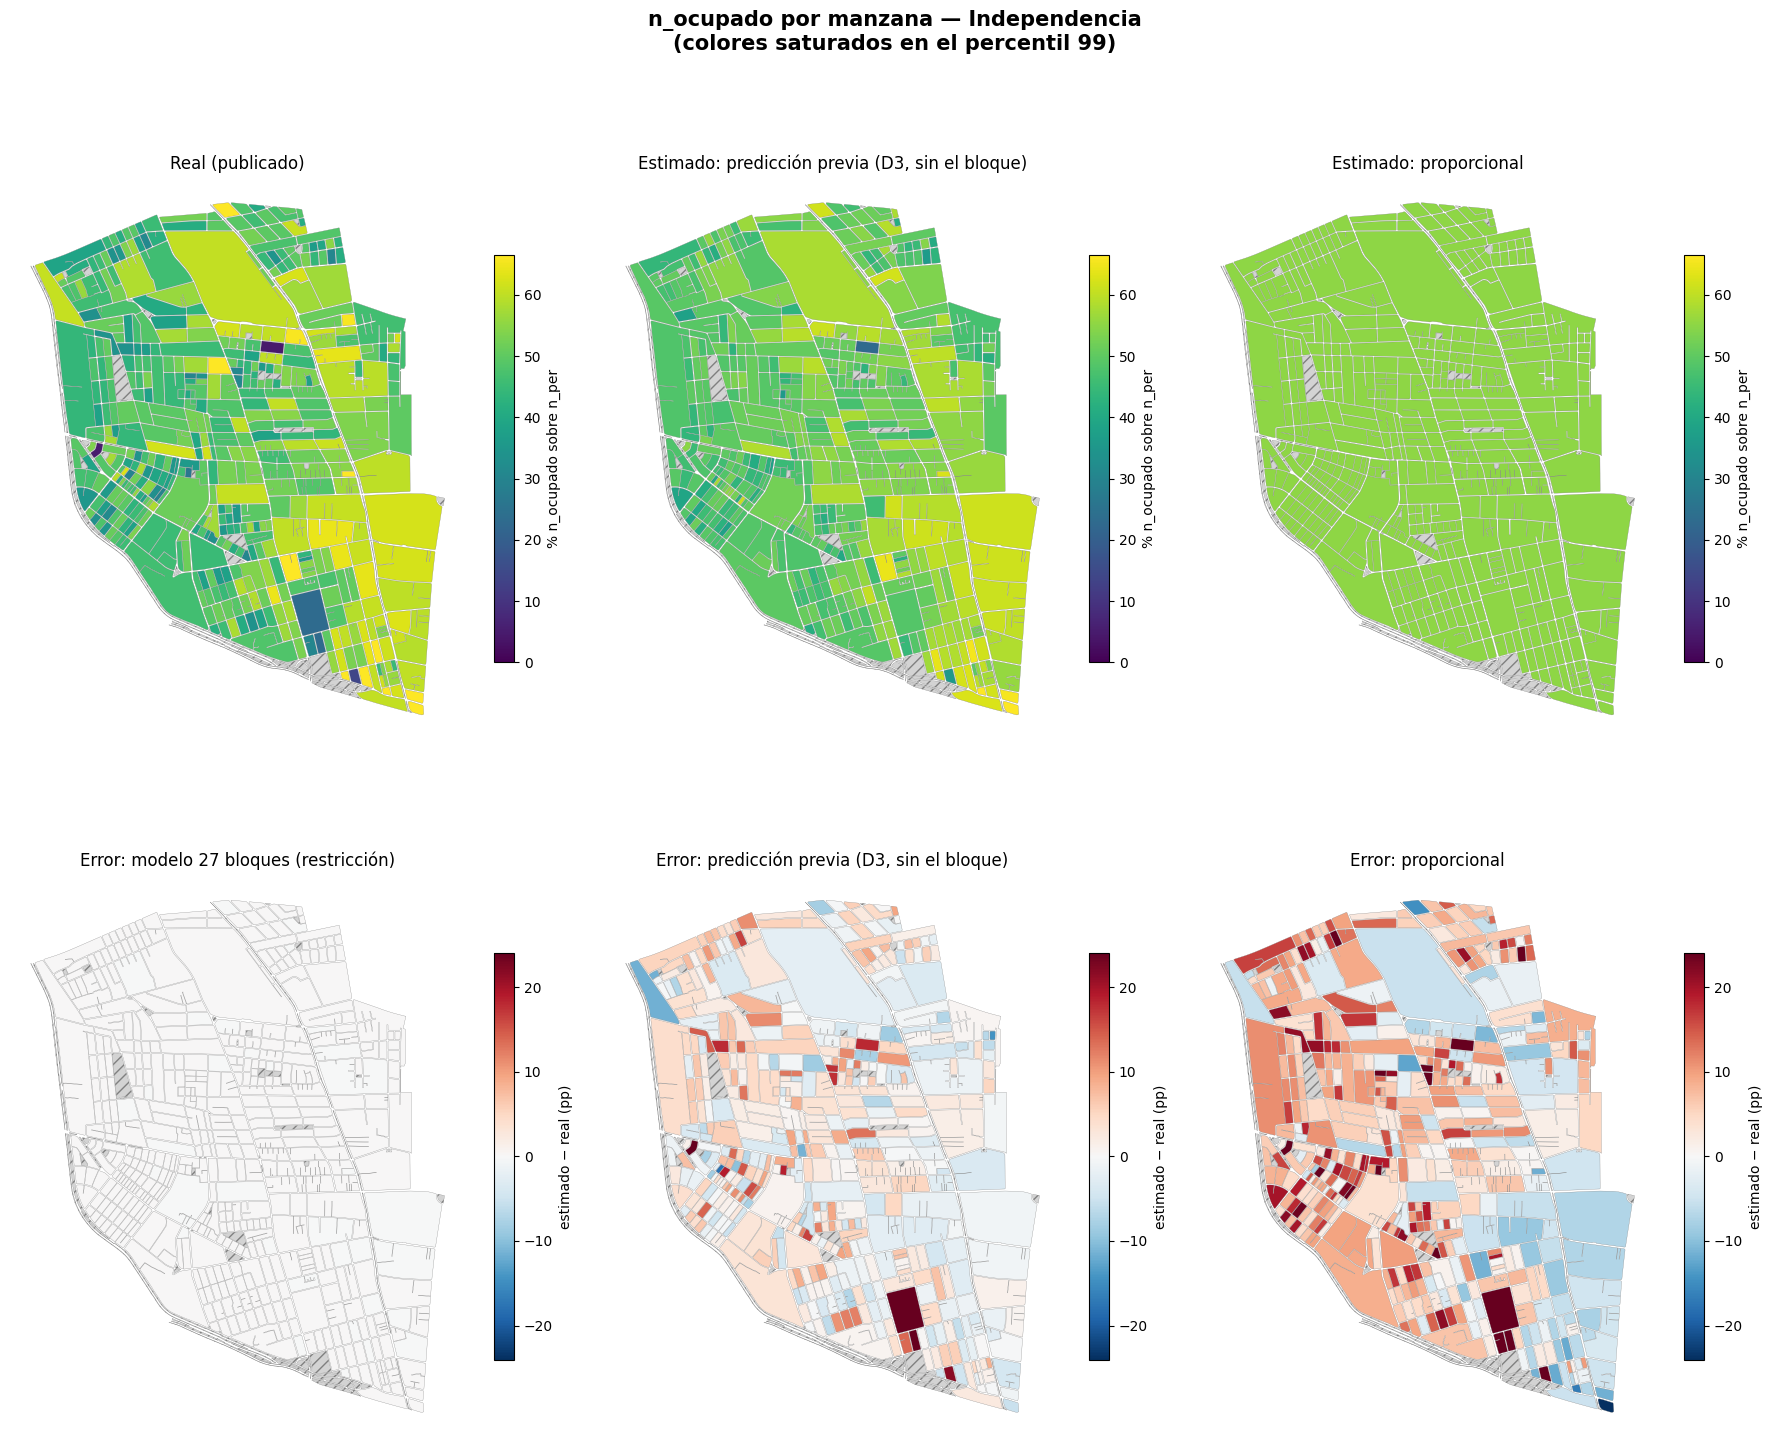

In [3]:
# D5. Mapa por manzana: % real vs % estimado de una categoría, y su error
nuevos = [b for b in bloques_27 if b not in modelo_d3["bloques"]]
BLOQUE_MAPA, CATEGORIA_MAPA = "fuerza_trabajo", 0  # 0 = ocupados; cualquier bloque de `nuevos`
assert BLOQUE_MAPA in nuevos, "el bloque debe estar fuera del modelo de D3 para que la predicción previa sea LOO"
nombre_cat = inv.marginales[BLOQUE_MAPA]["categorias"][CATEGORIA_MAPA][0]

pred_previa, nu_k, cod = predecir_bloque(inv, modelo_d3, BLOQUE_MAPA)  # modelo de D3: no contiene el bloque
pred_prop = (np.bincount(cod, minlength=nu_k.shape[0]) / len(cod))[:, None] * nu[None, :]
pred_27 = proyectar(modelo_27, BLOQUE_MAPA, nu_k.shape[0])               # aquí el bloque es restricción

def pct(x):
    return 100 * x / nu  # % sobre n_per de cada manzana

real = nu_k[CATEGORIA_MAPA]
estimaciones = {
    "modelo 27 bloques (restricción)": pred_27[CATEGORIA_MAPA],
    "predicción previa (D3, sin el bloque)": pred_previa[CATEGORIA_MAPA],
    "proporcional": pred_prop[CATEGORIA_MAPA],
}
ok = ~np.isnan(real)
print(f"{nombre_cat}: total real={np.nansum(real):.0f} | manzanas con dato={ok.sum()} | % comunal={100 * np.nansum(real) / nu[ok].sum():.1f}%")
for k, est in estimaciones.items():
    e_pp = pct(est - real)[ok]
    print(f"  {k:<38}: SRMSE={srmse(est, real):.4f} | error abs medio={np.abs(e_pp).mean():.2f} pp "
          f"| p95={np.percentile(np.abs(e_pp), 95):.2f} pp | corr(% real, % est)={np.corrcoef(pct(real)[ok], pct(est)[ok])[0, 1]:.3f}")

# Unión con la cartografía (todas las manzanas del parquet; las sin población quedan sin dato)
df_mapa = pd.DataFrame({"MANZENT": manzanas_ids, "real_pct": pct(real)})
for k, est in estimaciones.items():
    df_mapa[f"est_{k}"] = pct(est)
    df_mapa[f"err_{k}"] = pct(est - real)
mapa_d5 = mapa_comuna.merge(df_mapa, on="MANZENT", how="left")
print("manzanas en el mapa:", len(mapa_d5), "| con dato:", mapa_d5["real_pct"].notna().sum(),
      "| manzanas del modelo sin geometría:", len(set(manzanas_ids.tolist()) - set(mapa_comuna["MANZENT"].tolist())))

sin_dato = {"color": "lightgrey", "edgecolor": "0.5", "hatch": "///", "label": "Sin dato"}
nombres_est = list(estimaciones)
vmax_pct = np.nanpercentile(df_mapa[["real_pct"] + [f"est_{k}" for k in nombres_est]].to_numpy(), 99)
vmax_err = np.nanpercentile(np.abs(df_mapa[[f"err_{k}" for k in nombres_est]].to_numpy()), 99)

fig, axes = plt.subplots(2, 3, figsize=(18, 16))
arriba = [("real_pct", "Real (publicado)")] + [(f"est_{k}", f"Estimado: {k}") for k in nombres_est[1:]]
for ax, (col, titulo) in zip(axes[0], arriba):
    mapa_d5.plot(column=col, cmap="viridis", vmin=0, vmax=vmax_pct, linewidth=0.2, edgecolor="0.5", ax=ax,
                 legend=True, legend_kwds={"label": f"% {nombre_cat} sobre n_per", "shrink": 0.5}, missing_kwds=sin_dato)
    ax.set_title(titulo, fontsize=12)
    ax.axis("off")
for ax, k in zip(axes[1], nombres_est):
    mapa_d5.plot(column=f"err_{k}", cmap="RdBu_r", vmin=-vmax_err, vmax=vmax_err, linewidth=0.2, edgecolor="0.5", ax=ax,
                 legend=True, legend_kwds={"label": "estimado − real (pp)", "shrink": 0.5}, missing_kwds=sin_dato)
    ax.set_title(f"Error: {k}", fontsize=12)
    ax.axis("off")
plt.suptitle(f"{nombre_cat} por manzana — Independencia\n(colores saturados en el percentil 99)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()